# Comportement asymptotique des proportions

Les notebooks précédents ont étudié :
- la réplication expérimentale du théorème de Janson ;
- l’influence des paramètres sur la domination permanente ;
- le temps empirique de stabilisation de cette domination.

Nous étudions maintenant le comportement à long terme du processus.

L’objectif est de mieux comprendre comment une dynamique discrète, définie tirage après tirage, peut conduire progressivement à un comportement asymptotique stable.

Cette question est directement liée à la preuve du théorème de Janson, qui repose sur l’étude du comportement à long terme des trajectoires.

## Proportion de boules noires

La quantité naturelle à observer est la proportion de boules noires dans l’urne :

$$
P_n = \frac{B_n}{B_n + W_n}.
$$

Cette proportion permet de suivre la domination relative des boules noires au cours du temps.

Si \(P_n > 1/2\), alors les boules noires sont majoritaires.

Si \(P_n\) se rapproche de \(1\), cela signifie que la domination noire devient très forte relativement au nombre total de boules.

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from src.urn import PolyaUrn

# Directory for exported figures
FIG_DIR = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Utility function
def save_fig(name, ext="png"):

    plt.savefig(
        os.path.join(FIG_DIR, f"{name}.{ext}"),
        dpi=300,
        bbox_inches="tight"
    )

## Simulation d’une trajectoire longue

Nous commençons par observer une trajectoire individuelle sur un horizon plus long.

Les paramètres choisis satisfont les hypothèses du théorème de Janson :

$$
B_0 > W_0
\quad \text{et} \quad
m_b > m_w.
$$

L’objectif est d’observer l’évolution de la proportion :

$$
P_n = \frac{B_n}{B_n + W_n}.
$$

In [3]:
n_steps = 5000

urn = PolyaUrn(
    balls={"black": 10, "white": 5},
    reinforcements={"black": 2, "white": 1}
)

urn.simulate(n_steps)

black_path = np.array([state["black"] for state in urn.history])
white_path = np.array([state["white"] for state in urn.history])

proportion_black = black_path / (black_path + white_path)

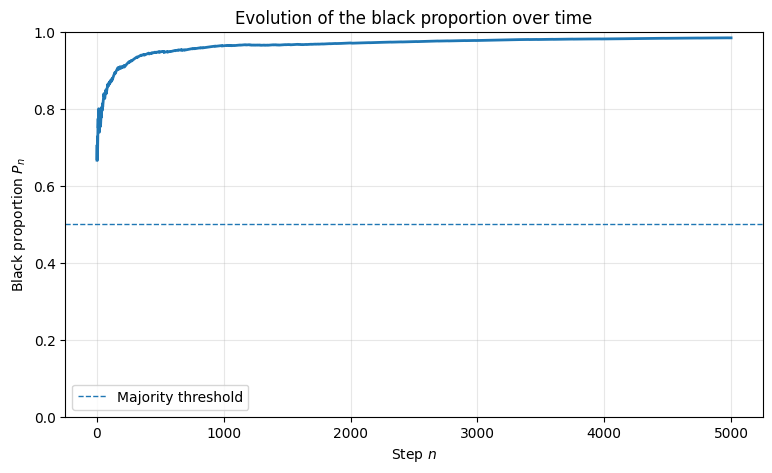

In [4]:
plt.figure(figsize=(9, 5))

plt.plot(
    proportion_black,
    linewidth=2
)

plt.axhline(
    0.5,
    linestyle="--",
    linewidth=1,
    label="Majority threshold"
)

plt.xlabel("Step $n$")
plt.ylabel(r"Black proportion $P_n$")

plt.title("Evolution of the black proportion over time")

plt.ylim(0, 1)

plt.grid(alpha=0.3)
plt.legend()

save_fig("black_proportion_validation")

plt.show()

## Interprétation de la trajectoire

La trajectoire montre comment la proportion de boules noires évolue progressivement au cours du temps.

Dans le régime étudié, les boules noires possèdent à la fois :
- un avantage initial ;
- un avantage de renforcement.

Ces deux effets favorisent la stabilisation de la proportion au-dessus du seuil \(1/2\).

Cette observation fournit une intuition importante : la domination permanente peut être comprise comme le résultat progressif d’un mécanisme de renforcement cumulatif.

## Plusieurs trajectoires indépendantes

Une seule trajectoire ne suffit pas à décrire le comportement probabiliste du processus.

Nous simulons maintenant plusieurs trajectoires indépendantes afin d’observer la variabilité des comportements possibles.

L’objectif est de distinguer :
- le comportement typique ;
- les fluctuations initiales ;
- la stabilisation progressive des proportions.

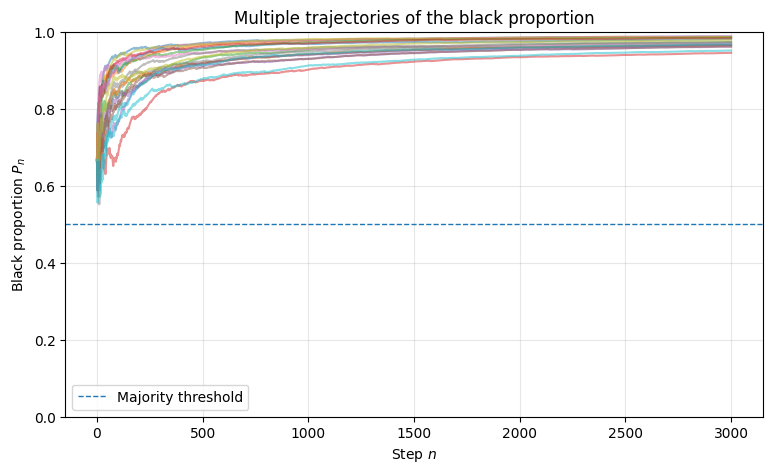

In [5]:
n_trajectories = 20
n_steps = 3000

plt.figure(figsize=(9, 5))

for _ in range(n_trajectories):

    urn = PolyaUrn(
        balls={"black": 10, "white": 5},
        reinforcements={"black": 2, "white": 1}
    )

    urn.simulate(n_steps)

    black_path = np.array([state["black"] for state in urn.history])
    white_path = np.array([state["white"] for state in urn.history])

    proportion_black = black_path / (black_path + white_path)

    plt.plot(
        proportion_black,
        alpha=0.5
    )

plt.axhline(
    0.5,
    linestyle="--",
    linewidth=1,
    label="Majority threshold"
)

plt.xlabel("Step $n$")
plt.ylabel(r"Black proportion $P_n$")

plt.title("Multiple trajectories of the black proportion")

plt.ylim(0, 1)

plt.grid(alpha=0.3)
plt.legend()

save_fig("multiple_black_proportion_trajectories")

plt.show()

## Observation

Les trajectoires simulées montrent que les fluctuations sont principalement visibles au début du processus.

À mesure que le nombre de tirages augmente, l’effet du renforcement devient plus important.

Dans le régime étudié, la plupart des trajectoires restent au-dessus du seuil de majorité \(1/2\), ce qui est cohérent avec les résultats obtenus dans les notebooks précédents.

Cette visualisation permet de passer d’une lecture événementielle de la domination permanente à une lecture dynamique du comportement asymptotique.

## Moyenne empirique des proportions

Nous étudions maintenant la proportion moyenne de boules noires sur plusieurs trajectoires.

Pour chaque instant \(n\), nous calculons la moyenne empirique :

$$
\overline{P}_n
=
\frac{1}{N}
\sum_{i=1}^{N}
P_n^{(i)}.
$$

Cette quantité permet d’observer le comportement moyen du processus sur un grand nombre de simulations.

In [6]:
n_simulations = 500
n_steps = 3000

all_proportions = []

for _ in range(n_simulations):

    urn = PolyaUrn(
        balls={"black": 10, "white": 5},
        reinforcements={"black": 2, "white": 1}
    )

    urn.simulate(n_steps)

    black_path = np.array([state["black"] for state in urn.history])
    white_path = np.array([state["white"] for state in urn.history])

    proportion_black = black_path / (black_path + white_path)

    all_proportions.append(proportion_black)

all_proportions = np.array(all_proportions)

mean_proportion = all_proportions.mean(axis=0)
lower_quantile = np.quantile(all_proportions, 0.10, axis=0)
upper_quantile = np.quantile(all_proportions, 0.90, axis=0)

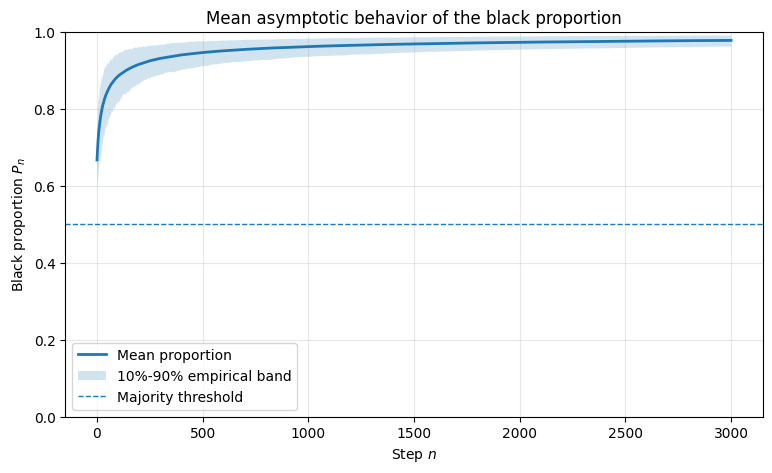

In [7]:
plt.figure(figsize=(9, 5))

plt.plot(
    mean_proportion,
    linewidth=2,
    label="Mean proportion"
)

plt.fill_between(
    np.arange(len(mean_proportion)),
    lower_quantile,
    upper_quantile,
    alpha=0.2,
    label="10%-90% empirical band"
)

plt.axhline(
    0.5,
    linestyle="--",
    linewidth=1,
    label="Majority threshold"
)

plt.xlabel("Step $n$")
plt.ylabel(r"Black proportion $P_n$")

plt.title("Mean asymptotic behavior of the black proportion")

plt.ylim(0, 1)

plt.grid(alpha=0.3)
plt.legend()

save_fig("mean_black_proportion_empirical_band")

plt.show()

## Interprétation

La moyenne empirique des proportions met en évidence une tendance stable au cours du temps.

La bande empirique permet également d’observer la dispersion des trajectoires.

Dans le régime étudié, cette dispersion reste limitée et la proportion moyenne des boules noires demeure nettement au-dessus du seuil \(1/2\).

Ce résultat renforce l’intuition selon laquelle l’avantage initial et l’asymétrie du renforcement produisent une domination durable.

## Lien avec la preuve du théorème

Le théorème de Janson porte sur un événement défini sur un horizon infini :

$$
A = \{B_n > W_n,\ \forall n \geq 0\}.
$$

Les simulations ne peuvent pas démontrer directement cet événement, car elles restent limitées à un horizon fini.

Cependant, l’étude des proportions permet de comprendre le mécanisme probabiliste sous-jacent.

Lorsque la proportion des boules noires reste durablement au-dessus de \(1/2\), cela suggère que la trajectoire s’éloigne progressivement de la zone où une inversion de domination est probable.

Cette idée est proche de l’intuition de la preuve : le comportement à long terme du processus devient déterminant pour comprendre la possibilité d’une domination permanente.

## Conclusion

Ce notebook a étudié le comportement asymptotique empirique des proportions dans une urne de Pólya généralisée.

Nous avons observé l’évolution de la quantité :

$$
P_n = \frac{B_n}{B_n + W_n}.
$$

Les simulations montrent que, dans le régime satisfaisant les hypothèses du théorème de Janson, la proportion de boules noires reste généralement au-dessus du seuil de majorité et tend à se stabiliser à long terme.

Cette analyse complète les notebooks précédents :
- le notebook 2 étudiait la réplication expérimentale du théorème ;
- le notebook 3 étudiait la sensibilité aux paramètres ;
- le notebook 4 étudiait le temps de stabilisation ;
- ce notebook met en évidence le comportement asymptotique des proportions.

Cette dernière étape permet de mieux comprendre le passage d’un processus discret, défini tirage après tirage, vers un comportement stable à long terme.

Elle fournit ainsi une intuition complémentaire pour la discussion de la preuve du théorème dans l’article final.